In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [2]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")

In [3]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [4]:
uni_key = {uni:key for key, uni in enumerate(data_filiacao["filiacao padronizada"].unique())}

In [5]:
css4_colors = list(mcolors.CSS4_COLORS.keys())

# You can use the first 130 of these colors
palette_130 = css4_colors[:data_filiacao["filiacao padronizada"].unique().shape[0]]

## Triângulos

In [6]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas_single_undirected = nx.Graph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas_single_undirected.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [7]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas_single_undirected.has_edge(orcid_orient, orcid_aval):
            grafo_defesas_single_undirected[orcid_orient][orcid_aval]["weight"] -=- 1
            continue
        grafo_defesas_single_undirected.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"], weight=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [8]:
triangules = nx.triangles(grafo_defesas_single_undirected)

In [15]:
info

{'nome': 'BULGARELI, J V',
 'filiacao': 'Universidade Federal de Uberlândia',
 'genero': 'Feminino',
 'filiacao_genero': 'Feminino_externo',
 'bipartite': 1,
 'marker': 'F',
 'cor_bin': 'blue',
 'cor': 'maroon'}

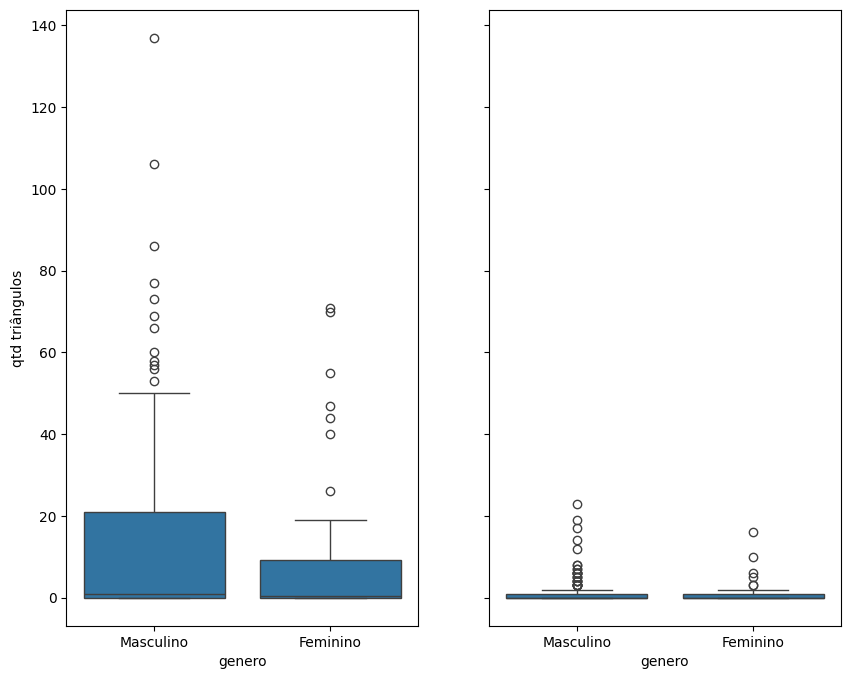

In [ ]:
df_tri = collections.defaultdict(list)
for person, qtd in triangules.items():
    info = grafo_defesas_single_undirected.nodes[person]
    df_tri["genero"].append(info["genero"])
    df_tri["qtd triângulos"].append(qtd)
    df_tri["filiacao_genero"].append(info["filiacao_genero"])
df_tri = pd.DataFrame(df_tri)
fig, ax = plt.subplots(ncols=2, figsize=(10,8), sharey=True)
sns.boxplot(data=df_tri[df_tri["filiacao_genero"].str.endswith("interno")], x="genero", y="qtd triângulos",
            ax=ax[0])
sns.boxplot(data=df_tri[df_tri["filiacao_genero"].str.endswith("externo")], x="genero", y="qtd triângulos",
            ax=ax[1])
plt.show()

## Clusterização

In [23]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas_single_directed = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas_single_directed.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [24]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas_single_directed.has_edge(orcid_orient, orcid_aval):
            grafo_defesas_single_directed[orcid_orient][orcid_aval]["weight"] -=- 1
            continue
        grafo_defesas_single_directed.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"], weight=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [30]:
nx.average_clustering(grafo_defesas_single_directed)

0.1810974630828736

In [29]:
np.mean([v for v in clustering.values()])

np.float64(0.18109746308287375)

In [25]:
clustering = nx.clustering(grafo_defesas_single_directed)

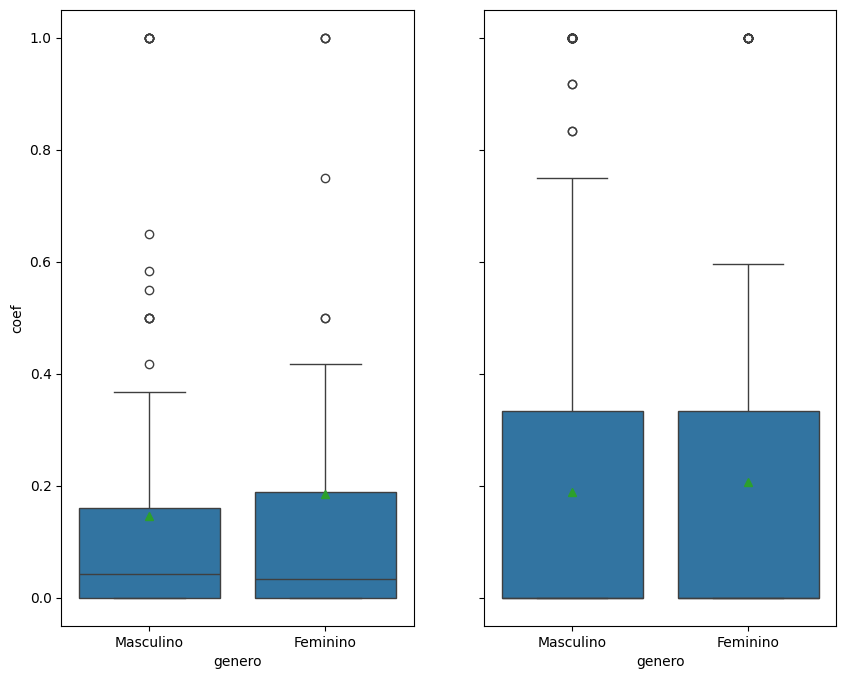

In [33]:
df_clustering = collections.defaultdict(list)
for person, coef in clustering.items():
    info = grafo_defesas_single_directed.nodes[person]
    df_clustering["genero"].append(info["genero"])
    df_clustering["coef"].append(coef)
    df_clustering["filiacao_genero"].append(info["filiacao_genero"])
df_clustering = pd.DataFrame(df_clustering)
fig, ax = plt.subplots(ncols=2, figsize=(10,8), sharey=True)
sns.boxplot(data=df_clustering[df_clustering["filiacao_genero"].str.endswith("interno")],
            x="genero", y="coef", showmeans=True,
            ax=ax[0])
sns.boxplot(data=df_clustering[df_clustering["filiacao_genero"].str.endswith("externo")],
            x="genero", y="coef", showmeans=True,
            ax=ax[1])
plt.show()

## Comunidade

In [35]:
coms = nx.community.girvan_newman(grafo_defesas_single_directed)

In [36]:
for c in coms:
    break

In [45]:
for c_ in c:
    print(len(c_))

479
1
1
1
1
1
1
15
3
1
1
1
4
3
1
